In [1]:
import time
from ugot import ugot
got = ugot.UGOT()
got.initialize('192.168.1.230')
print("UGOT connected.")
got.play_audio_tts("Hello,how are you doing?", 0, False)
got.show_light_rgb_effect(0,255,0,3)
time.sleep(2)
got.turn_off_lights()

192.168.1.230:50051
UGOT connected.


In [ ]:
Laser1 = got.read_distance_data(21)
Laser2 = got.read_distance_data(51)
print(Laser1)
print(Laser2)


In [2]:
# OpenCV libriary
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image,display,clear_output

# Level 4 Term 1

## Session 1

1. tuple

In [ ]:
my_friend1 = ["apple",1000,"Mars",True,["red","yellow"]]  # list can be changed.
my_friend2 =("apple",1000,"Mars",True,("red","yellow"))  # tuple can not be changed.
print(my_friend1)
print(my_friend2)
print(type(my_friend1))
print(type(my_friend2))

2. access tuple

In [ ]:
print(my_friend2[0])
print(my_friend2[4][1])
print(my_friend2[1:4])
print(my_friend2 [::-1])

3. unpack tuple

In [ ]:
my_friend2 =("apple",1000,"Mars",True,("red","yellow"))  
name,age,home,handsome,color = my_friend2
print(name)
print(home,color)

In [ ]:
my_friend2 =("apple",1000,"Mars",True,("red","yellow"))
name,*others = my_friend2
print(name)  
name,*others,color = my_friend2
print(name,color)
*others,home = my_friend2
print(home)

In [ ]:
got.load_models["apriltag_qrcode"]
AP_info = got.get_apriltag_total_info()
AP_distance = AP_info[0][6]
AP_x = AP_info[0][1]

while True:
    AP_info = got.get_apriltag_total_info()
    AP_distance = AP_info[0][6]
    if AP_x > 340:
        got.mecanum_move_xyz(5,10,0)
    elif AP_x<300:
        got.mecanum_move_xyz(-5,10,0)
    elif AP_distance> 0.2:
        got.mecanum_move_xyz(0,10,0)
    else:
        got.mecanum_stop()
        break


# Level 4 Term 1

## Session 2

1. face recognition

In [ ]:
got.load_models(["face_recognition"])

In [ ]:
import time
got.face_recognition_add_name("Coley")
time.sleep(3)

In [ ]:
got.load_models(["face_recognition"])
got.open_camera()
print("The camera is on")
time.sleep(2)
face_info = got.get_face_recognition_total_info()
face_width = face_info[0][4]
face_x = face_info[0][1]

for i in range(5):
    print(f"The face_width is : {face_width}, and the face_x is: {face_x}.")
    time.sleep(1)

In [ ]:
while True:
    face_info = got.get_face_recognition_total_info()
    name = face_info[0][0]
    if not face_info:
        continue

    if name == "Ananya":
        print("Hello Ananya, nice to meet you!")
        break
    else:
        print("Hello stranger")
        break


In [ ]:
import time
got.open_camera()
time.sleep(1)

while True:
    face_info = got.get_face_recognition_total_info()
    if not face_info:
        got.mecanum_move_xyz(0,0,15)
    else:
        face_x = face_info[0][1]
        if face_x < 300:
            got.mecanum_move_xyz(0,0,15)
        else:
            print(face_x)
            got.mecanum_stop()
            break

while True:
    face_info = got.get_face_recognition_total_info()
    width = face_info[0][4]
    if width > 80:
        got.mecanum_stop()
        break
    else:
        got.mecanum_move_xyz(0,15,0)

In [ ]:
import time
got.open_camera()
time.sleep(1)

while True:
    face_info = got.get_face_recognition_total_info()
    if not face_info:
        got.mecanum_move_xyz(0,0,15)
        continue
    face_x = face_info[0][1]
    width = face_info[0][4]

    if face_x < 300:
        got.mecanum_move_xyz(0,0,15)
    elif width < 80:
        got.mecanum_move_xyz(0,10,0)
    else:
        got.mecanum_stop()
        break


## Session 3

1. face recognition and tuple

In [ ]:
import time
got.face_recognition_add_name("Ryan")
time.sleep(3)

In [ ]:
Ryan_profile = ("Ryan","Good morning Ryan, how are you doing?","red")
Coly_profile = ("Coly","Good afternoon Coley, it's nice to see you.","blue")
Arjun_profile = ("Arjun","Good evening Arjun, have a good night.","yellow")
stranger_info = ("Unknown","Hello, who are you?","unknown")

profiles = [Ryan_profile,Coly_profile,Arjun_profile,stranger_info]

while True:
    face_info = got.get_face_recognition_total_info()

    if not face_info:
        continue

    if face_info:
        detected_name = face_info[0][0]
        matched_profile =stranger_info 
        for profile in profiles:
            if profile[0] == detected_name:
                matched_profile = profile
                break

        print(f"name: {matched_profile[0]}")
        print(f"Greetings:{matched_profile[1]}")
        print(f"The color you like is: {matched_profile[2]}")
    
    time.sleep(5)

2. Robotic guard

In [ ]:
import time
start_time = time.time()
duration = 10

while time.time() - start_time < duration:
    face_info = got.get_face_recognition_total_info()
    
    if not face_info:
        continue

    if face_info:
        face_info = got.get_face_recognition_total_info()
        name = face_info[0][0]
        if name == "Ryan":
            print("Hello Ryan")
            got.show_light_rgb_effect(0,255,0,2)
            time.sleep(2)
            got.turn_off_lights()
            got.play_audio_tts("Hello Ryan, how are you?",0,True)
        
        elif name == "Coley":
            print("Good evening, Coley")
            got.show_light_rgb_effect(255,255,255,2)
            time.sleep(2)
            got.turn_off_lights()
            got.play_audio_tts("Hello Coley, how are you?",0,True)
            
        elif name == "Arjun":
            print("Good evening,Arjun")
            got.show_light_rgb_effect(100,100,100,2)
            time.sleep(2)
            got.turn_off_lights()
            got.play_audio_tts("Hello Arjun, how are you?",0,True)
            
        else:
            got.show_light_rgb_effect(0,0,0,2)
            time.sleep(2)
            got.turn_off_lights()

In [ ]:
while True:
    face_info = got.get_face_recognition_total_info()
    if face_info:
        got.mecanum_stop()
        break
    got.mecanum_move_xyz(0,0,15)

## Session 4

1. voice recognition

In [ ]:
question = got.start_audio_asr()
got.start_audio_nlp(question, True)
print(question)

In [ ]:
while True:
    question = got.start_audio_asr()
    if not question:
        continue

    command = question.lower().strip()
    if"stop" in command:
        print("It's very nict talking to you, see you next time!")
        break

    if "forward" in command:
        got.mecanum_move_speed_times(0,20,50,1)
    elif "backward" in command:
        got.mecanum_move_speed_times(1,20,50,1)
    elif "right" in command:
        got.mecanum_turn_speed_times(3,30,90,2)
    elif "left" in command:
        got.mecanum_turn_speed_times(2,30,90,2)

In [ ]:
got.mecanum_move_speed_times(0,30,50,1)

## Session 5

1. dictionary

In [ ]:
my_friend1 = ["Jack",1000,"Mars","Apple",["yellow","blue"]]
my_friend2 = ("Jack",1000,"Mars","Apple",("yellow","blue"))
print(type(my_friend1))
print(type(my_friend2))
print(my_friend1[4][0])
print(my_friend2[4][0])

In [ ]:
my_friend3 = {
    "name":"Jack",  # key : value pair
    "age":1000,
    "Homeland":"Mars",
    "boy friend":"Apple",
    "tan":["yellow","blue"],
}
print(my_friend3)
print(type(my_friend3))

2. access dictionary

In [ ]:
print(my_friend3["name"])
print(my_friend3.keys())
print(my_friend3.values())
print(my_friend3.items())


3. change items

In [ ]:
my_friend3["name"] = "John"
my_friend3["favorite subject"] = "Coding"


In [ ]:
print(my_friend3)

4. loop dictionary

In [ ]:
my_friend4 = {
    "name":"Jack",  # key : value pair
    "age":1000,
    "Homeland":"Mars",
    "boy friend":"Apple",
    "tan":["yellow","blue"],
    "favorite subject" : "coding",
}

In [ ]:
for i in my_friend4:
    print(i)
for i in my_friend4.values():
    print(i)
for i in my_friend4.items():
    print(i)

In [ ]:
for i,j in my_friend4.items():
    print(i,j)

5. change the color with voice recognition

In [ ]:
colors = {
    "red":(255,0,0),
    "yellow":(255,255,0),
    "blue":(0,0,255),
    "white":(255,255,255),
}
print("What's your favorite color?")

while True:
    question = got.start_audio_asr()
    if not question:
        continue
    got.start_audio_nlp(question, False)
    print(question)

    command = question.lower().strip()

    for color,(r,g,b) in colors.items():
        if color in command:
            got.show_light_rgb_effect(r,g,b,3)
            print(f"I am showing {color} now.")
            time.sleep(2)
        
    if "stop" in command:
        print("Game over!")
        got.turn_off_lights()
        break

## Session 6

In [ ]:
def speech_to_drive():
    movements = {
        "forward":(0,10,0),
        "backward":(0,-10,0),
        "left":(-10,0,0),
        "right":(10,0,0),
        "rotate":(0,0,10),
        }
    print("Please let me know how to move.")

    while True:
        question = got.start_audio_asr()
        if not question:
            continue

        got.start_audio_nlp(question, False)
        print(question)

        command = question.lower().strip()

        for direction,(x,y,z) in movements.items():
            if direction in command:
                got.mecanum_move_xyz(x,y,z)
                print(f"I am moving{direction}.")
                break
                
        if "stop" in command:
            got.mecanum_stop()
            print("Gamve over!")
            break

In [ ]:
def face_recognition():
    import time
    got.open_camera()
    time.sleep(1)

    while True:
        face_info = got.get_face_recognition_total_info()
        if not face_info:
            got.mecanum_move_xyz(0,0,15)
        else:
            face_x = face_info[0][1]
            if face_x < 300:
                got.mecanum_move_xyz(0,0,15)
            else:
                print(face_x)
                got.mecanum_stop()
                break

    while True:
        face_info = got.get_face_recognition_total_info()
        width = face_info[0][4]
        if width > 80:
            got.mecanum_stop()
            break
        else:
            got.mecanum_move_xyz(0,15,0)

In [ ]:
speech_to_drive()

## Session 7

In [ ]:
def AP_recognition():
    import time
    got.load_models(["apriltag_qrcode"])
    got.open_camera()
    time.sleep(1)
    print("The camera is on.")

    while True:
        AP_info = got.get_apriltag_total_info()
        if not AP_info:
            continue
        AP_x = AP_info[0][1]
        AP_distance = AP_info[0][6]
        if AP_x > 340:
            got.mecanum_move_xyz(5,10,0)
        elif AP_x <300:
            got.mecanum_move_xyz(-5,10,0)
        elif AP_distance > 0.2:
            got.mecanum_move_xyz(0,10,0)
        else:
            got.mecanum_stop()
            break

In [ ]:
import time
got.load_models(["apriltag_qrcode"])
got.open_camera()
time.sleep(1)
print("The camera is on.")
AP_info = got.get_apriltag_total_info()

AP_x = AP_info[0][1]
start_time = time.time()

got.mechanical_joint_control(90,30,30,1000)
time.sleep(1)
got.mechanical_clamp_release()
time.sleep(1.5)

while time.time()-start_time <3:
    AP_info = got.get_apriltag_total_info()
    AP_x = AP_info[0][1]
    joint1 = int((AP_x-320)/10*-1)
    got.mechanical_joint_control(joint1,30,30,1000)
    time.sleep(1)

got.mechanical_joint_control(joint1,0,-70,1000)
time.sleep(1)
got.mechanical_clamp_close()
time.sleep(1.5)
got.mechanical_joint_control(90,30,30,1000)
time.sleep(1)


## Session 8/9

1. function liabrary

In [ ]:
# 1. AP recognition and approaching
def AP_recognition_approaching():
    import time
    got.load_models(["apriltag_qrcode"])
    got.open_camera()
    time.sleep(1)
    print("The camera is on.")

    while True:
        AP_info = got.get_apriltag_total_info()
        if not AP_info:
            continue
        AP_x = AP_info[0][1]
        AP_distance = AP_info[0][6]
        if AP_x > 340:
            got.mecanum_move_xyz(5,10,0)
        elif AP_x <300:
            got.mecanum_move_xyz(-5,10,0)
        elif AP_distance > 0.2:
            got.mecanum_move_xyz(0,10,0)
        else:
            got.mecanum_stop()
            break

# 2. AP recognition and pick up
def AP_pick_up():
    import time
    got.load_models(["apriltag_qrcode"])
    got.open_camera()
    time.sleep(1)
    print("The camera is on.")
    AP_info = got.get_apriltag_total_info()

    AP_x = AP_info[0][1]
    start_time = time.time()

    got.mechanical_joint_control(90,30,30,1000)
    time.sleep(1)
    got.mechanical_clamp_release()
    time.sleep(1.5)

    while time.time()-start_time <3:
        AP_info = got.get_apriltag_total_info()
        AP_x = AP_info[0][1]
        joint1 = int((AP_x-320)/10*-1)
        got.mechanical_joint_control(joint1,30,30,1000)
        time.sleep(1)

    got.mechanical_joint_control(joint1,0,-70,1000)
    time.sleep(1)
    got.mechanical_clamp_close()
    time.sleep(1.5)
    got.mechanical_joint_control(90,30,30,1000)
    time.sleep(1)

# 3. line follow
def line_follow():
    import time
    got.load_models(["line_recognition"])
    got.set_track_recognition_line(0)

    line_info = got.get_single_track_total_info()
    line_type = line_info[1]

    while line_type > 0:
        if not line_type:
            continue
        line_info = got.get_single_track_total_info()
        line_type = line_info[1]
        offset = line_info[0]
        degrees = int(0.2*offset)
        got.mecanum_move_xyz(0,25,degrees)
        time.sleep(0.05)

    got.mecanum_stop()

#4. put down
def put_down():
    got.mechanical_joint_control(90,0,-70,1000)
    time.sleep(1)
    got.mechanical_clamp_release()
    time.sleep(1.5)
    got.mechanical_joint_control(90,30,30,1000)
    time.sleep(1)
    got.mechanical_joint_control(0,30,30,1000)
    time.sleep(1)
    got.mechanical_clamp_close()
    time.sleep(1.5)

# 5. voice recognition
def speech_to_drive():
    movements = {
        "forward":(0,10,0),
        "backward":(0,-10,0),
        "left":(-10,0,0),
        "right":(10,0,0),
        "rotate":(0,0,10),
        }
    print("Please let me know how to move.")

    while True:
        question = got.start_audio_asr()
        if not question:
            continue

        got.start_audio_nlp(question, False)
        print(question)

        command = question.lower().strip()

        for direction,(x,y,z) in movements.items():
            if direction in command:
                got.mecanum_move_xyz(x,y,z)
                print(f"I am moving{direction}.")
                break
                
        if "stop" in command:
            got.mecanum_stop()
            print("Gamve over!")
            break

# 6. face recognition
def face_recognition_approach():
    import time
    got.load_models(["face_recognition"])
    got.open_camera()
    time.sleep(1)

    while True:
        face_info = got.get_face_recognition_total_info()  # Read ONCE per loop

        if not face_info:
            got.mecanum_move_xyz(0,8,0)
            continue

        face_x     = face_info[0][1]  # Center x-coordinate
        face_width = face_info[0][4]  # Width of bounding box (proxy for distance)

        if face_x > 340:                      # Face is too far RIGHT — strafe right + forward
            got.mecanum_move_xyz(5, 8, 0)
        elif face_x < 300:                    # Face is too far LEFT — strafe left + forward
            got.mecanum_move_xyz(-5, 8, 0)
        elif face_width < 100:                # Face centred but too small (far away) — move forward
            got.mecanum_move_xyz(0, 8, 0)
        else:                                 # Face centred AND close enough — stop
            got.mecanum_stop()
            break

In [ ]:
# final presentation challenge

AP_recognition_approaching()
time.sleep(0.5)
AP_pick_up()
time.sleep(0.5)
line_follow()
time.sleep(0.5)
speech_to_drive()
time.sleep(0.5)
face_recognition_approach()
time.sleep(0.5)
got.mecanum_turn_speed_times(3,30,90,2)
put_down()

# Level 4 Term 2

## Session 1

In [ ]:
import time
Laser1 = got.read_distance_data(21)
Laser2 = got.read_distance_data(51)

for i in range(4):
    Laser1 = got.read_distance_data(21)
    Laser2 = got.read_distance_data(51)
    print(f"The laser 1 value is {Laser1}")
    print(f"The laser 2 value is {Laser2}")
    time.sleep(1)

1. OpenCV

In [ ]:
pip install opencv-python

In [ ]:
pip install matplotlib

In [ ]:
Image("eagle.jpg")

In [ ]:
eagle = cv2.imread("eagle.jpg")
print("Loaded:", eagle is not None)

if eagle is not None:
    print("Shape(H,W,C):",eagle.shape)
    print("Dtype:",eagle.dtype)
    print("Top-left pixel(B,G,R):",eagle[0,0])

2. Array

In [ ]:
array1D = [1,2,3,4,5,6]
print(array1D)
print(type(array1D))

In [ ]:
array1D = [1,2,3,4,5,6]
print(array1D)
print(type(array1D))
list = ["yellow",1000,True,["apple","banana"]]
print(list)
print(type(list))

3. Array in Numpy

In [ ]:
# 1D array
import numpy as np
array1D = np.array([1,2,3,4,5,6])
print(f"1D Array:{array1D}")
print(f"Shape:{array1D.shape}")
print(type(array1D))

In [ ]:
# 2D array
array2D = np.array([[1,2,3],
                    [4,5,6]])
print(f"2D Array:{array2D}")
print(f"Shape:{array2D.shape}")
print(type(array2D))

In [ ]:
# 3D array
array3D = np.array([[[255,0,0],[0,255,0],[0,0,255]],
                    [[0,0,255],[0,255,0],[255,0,0]]])
print(f"3D Array:{array3D}")
print(f"Shape:{array3D.shape}")
print(type(array3D))

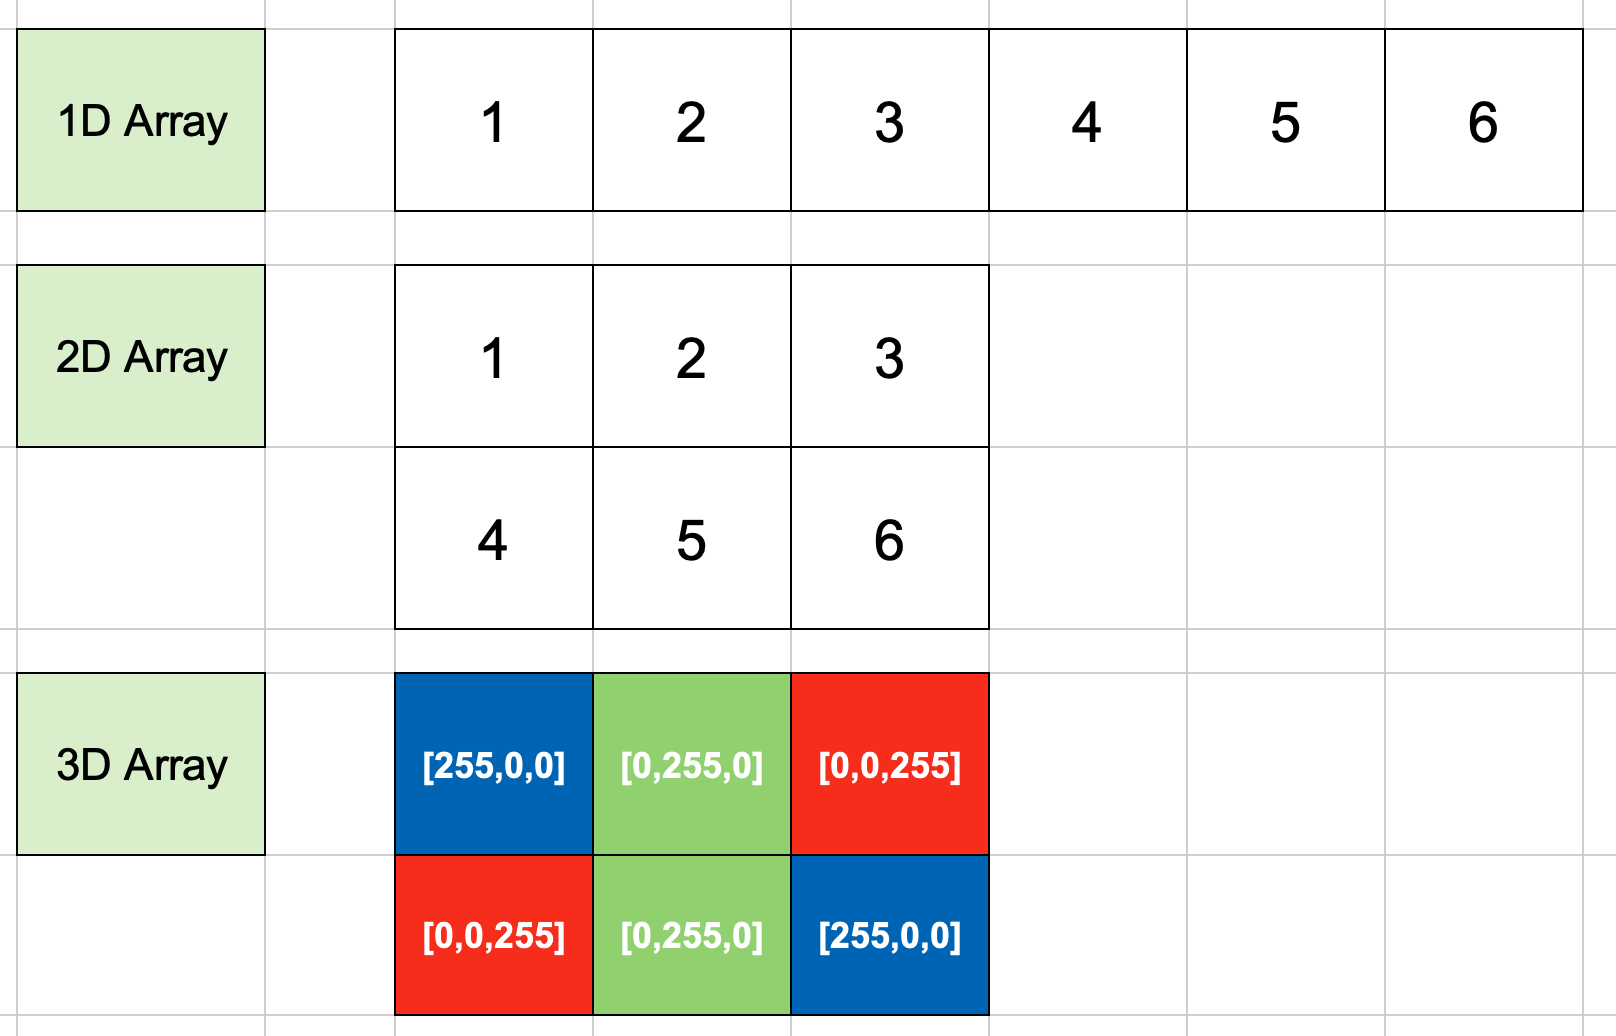

In [14]:
Image("Array.png")

In [ ]:
# 3D array
array3D = np.array([[[255,0,0],[0,255,0],[0,0,255],[255,0,0],[0,255,0],[0,0,255]],
                    [[255,0,0],[0,255,0],[0,0,255],[255,0,0],[0,255,0],[0,0,255]],
                    [[255,0,0],[0,255,0],[0,0,255],[255,0,0],[0,255,0],[0,0,255]],
                    [[255,0,0],[0,255,0],[0,0,255],[255,0,0],[0,255,0],[0,0,255]],
                    [[255,0,0],[0,255,0],[0,0,255],[255,0,0],[0,255,0],[0,0,255]],
                    [[255,0,0],[0,255,0],[0,0,255],[255,0,0],[0,255,0],[0,0,255]],])
print(f"3D Array:{array3D}")
print(f"Shape:{array3D.shape}")
print(type(array3D))

## Session 2

1. UGOT image display

The camera is on.
The raw data:b'\xff\xd8\xff\xe0\x00!AVI1\x00\x01\x01\x01\x00x\x00x\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\xff\xdb\x00C\x00(\x1b\x1e#\x1e\x19(# #-*(/<dA<77<zW\\Hd\x91\x7f\x98\x96\x8e\x7f\x8c\x89\xa0\xb4\xe6\xc3\xa0\xaa\xd9\xac\x89\x8c\xc8\x10\xca\xd9\xed\xf5\x01\x04\x01\x9b\xc0\x1a.\x18\xfa,\xe6\xfc\x01\xf7\xff\xdb\x00C\x01*--<4<uAAu\xf7\xa5\x8c\xa5\xf7\xf7\xf7\xf7\xf7\xf7\xf7\xf7\xf7\xf7\xf7\xf7\xf7\xf7\xf7\xf7\xf7\xf7\xf7\xf7\xf7\xf7\xf7\xf7\xf7\xf7\xf7\xf7\xf7\xf7\xf7\xf7\xf7\xf7\xf7\xf7\xf7\xf7\xf7\xf7\xf7\xf7\xf7\xf7\xf7\xf7\xf7\xf7\xf7\xf7\xff\xc0\x00\x11\x08\x01\xe0\x02\x80\x03\x01!\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1f\x00\x00\x01\x05\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b\xff\xc4\x00\xb5\x10\x00\x02\x01\x03\x03\x02\x04\x03\x05\x05\x04\x04\x00\x00\x01}\x01\x02\x03\x00\x04\x11\x05\x12!1A\x06\x13Qa\x07"q\x142\x81\x91\xa1\x08#B\xb1\xc1\x15R\xd1\xf0$3br\x82\t\n\x16\x

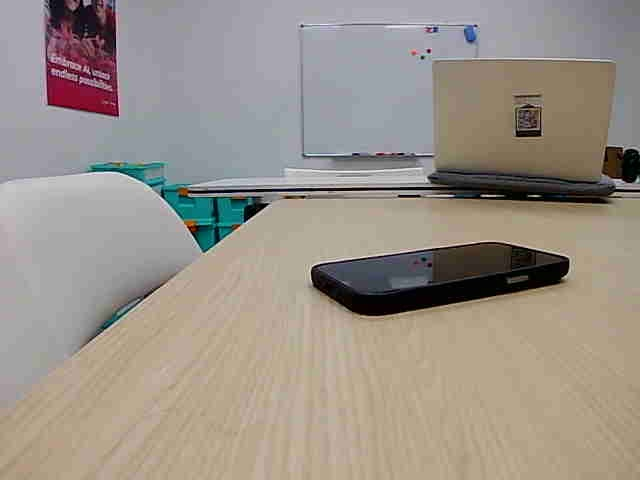

In [13]:
# step 1: turn on the camera
got.open_camera()
print("The camera is on.")

# step 2: get the raw data
picture = got.read_camera_data() 
print(f"The raw data:{picture}")
print(f"Data type:{type(picture)}")

# step 3: unpack the raw data, bytes to 1D array
picture = np.frombuffer(picture,np.uint8)
print(f"The data:{picture}")
print(f"Shape:{picture.shape}")
print(f"Data type:{type(picture)}")

# step 4: 1D array to 3D array
picture = cv2.imdecode(picture,cv2.IMREAD_COLOR)
print(f"The data:{picture}")
print(f"Shape:{picture.shape}")
print(f"Data type:{type(picture)}")

# step 5: pack 3D array for Jupyter
ok,picture_jpg = cv2.imencode(".jpg",picture)
print(f"The data:{picture}")
print(f"Shape:{picture.shape}")
print(f"Data type:{type(picture)}")

# step 6: show the image
display(Image(picture_jpg.tobytes()))

In [ ]:
Image("UGOT camera to image.png")

## Session 3

In [ ]:
print("The camera is on.")
ok,picture_jpg = cv2.imencode(".jpg",picture_bgr)
picture_1D = np.frombuffer(picture_raw,np.uint8)
picture_raw = got.read_camera_data()
got.open_camera()
display(Image(picture_jpg.tobytes()))
picture_bgr = cv2.imdecode(picture_1D,cv2.IMREAD_COLOR)  


1. security camera

In [ ]:
def smile_for_the_camera():
    got.open_camera()
    print("The camera is on.")
    picture_raw = got.read_camera_data()
    picture_1D = np.frombuffer(picture_raw,np.uint8)
    picture_bgr = cv2.imdecode(picture_1D,cv2.IMREAD_COLOR)  
    ok,picture_jpg = cv2.imencode(".jpg",picture_bgr)
    display(Image(picture_jpg.tobytes()))

In [ ]:
got.open_camera()
print("The camera is on!")

while True:
    Laser1 = got.read_distance_data(21)

    if Laser1>50:
        got.show_light_rgb_effect(0,255,0,3)
    else:
        got.show_light_rgb_effect(255,0,0,3)
        smile_for_the_camera()
        
        break
got.turn_off_lights()



2. image to video

In [ ]:
import cv2
import numpy as np
from IPython.display import Image,display, clear_output

got.open_camera()
print("The camera is on.")

for i in range(100):
    picture_raw = got.read_camera_data()

    if picture_raw is None:
        continue

    picture_1D = np.frombuffer(picture_raw,np.uint8)
    picture_bgr = cv2.imdecode(picture_1D,cv2.IMREAD_COLOR)  
    ok,picture_jpg = cv2.imencode(".jpg",picture_bgr)
    display(Image(picture_jpg.tobytes()))
    clear_output(True)

In [ ]:
import cv2
import numpy as np
from IPython.display import Image,display, clear_output

got.open_camera()
print("The camera is on!")

while True:
    Laser1 = got.read_distance_data(21)

    if Laser1>50:
        got.show_light_rgb_effect(0,255,0,3)
    else:
        got.show_light_rgb_effect(255,0,0,3)
        got.play_audio_tts("Go away or I will call the police!",1,False)
        for i in range(100):
            picture_raw = got.read_camera_data()

            if picture_raw is None:
                continue

            picture_1D = np.frombuffer(picture_raw,np.uint8)
            picture_bgr = cv2.imdecode(picture_1D,cv2.IMREAD_COLOR)  
            ok,picture_jpg = cv2.imencode(".jpg",picture_bgr)
            display(Image(picture_jpg.tobytes()))
            clear_output(True)
        break

got.turn_off_lights()

## Session 4

1. BRG to HSV

In [ ]:
import numpy as np
import cv2
from IPython.display import display, Image

got.open_camera()
print("The camera is on!")
picture_raw = got.read_camera_data()

if picture_raw is None:
    raise Exception ("No camera data found.")

picture_1D = np.frombuffer(picture_raw,np.uint8)
picture_bgr = cv2.imdecode(picture_1D,cv2.IMREAD_COLOR)  

if picture_bgr is None:
    raise Exception("Imdecode failed, please check the camera or data.")

# convert BGR to HSV
picture_hsv = cv2.cvtColor(picture_bgr, cv2.COLOR_BGR2HSV)

ok,picture_hsv = cv2.imencode(".jpg",picture_hsv)
display(Image(picture_hsv.tobytes()))


In [ ]:
Image("BGR2HSV.png")

In [ ]:
Image("Color wheel.png")

2. make a mask

In [ ]:
import numpy as np
import cv2
from IPython.display import display, Image

# open camera and get BGR
got.open_camera()
print("The camera is on!")
picture_raw = got.read_camera_data()

if picture_raw is None:
    raise Exception ("No camera data found.")

picture_1D = np.frombuffer(picture_raw,np.uint8)
picture_bgr = cv2.imdecode(picture_1D,cv2.IMREAD_COLOR)  

if picture_bgr is None:
    raise Exception("Imdecode failed, please check the camera or data.")

# convert BGR to HSV
picture_hsv = cv2.cvtColor(picture_bgr, cv2.COLOR_BGR2HSV)

# detect the color
lower_color = np.array([80,150,60])
upper_color = np.array([120,255,170])

# create a mask only pixel
mask = cv2.inRange(picture_hsv,lower_color,upper_color)

# show the black-white image
ok,mask = cv2.imencode(".jpg",mask)
display(Image(mask.tobytes()))

## Session 5

1. color only mask

In [ ]:
Image("Yellow only.png")

2.blue cube only mask

In [ ]:
import numpy as np
import cv2
from IPython.display import display, Image

# open camera and get BGR
got.open_camera()
print("The camera is on!")
picture_raw = got.read_camera_data()

if picture_raw is None:
    raise Exception ("No camera data found.")

picture_1D = np.frombuffer(picture_raw,np.uint8)
picture_bgr = cv2.imdecode(picture_1D,cv2.IMREAD_COLOR)  

if picture_bgr is None:
    raise Exception("Imdecode failed, please check the camera or data.")

# convert BGR to HSV
picture_hsv = cv2.cvtColor(picture_bgr, cv2.COLOR_BGR2HSV)

# detect the color
lower_color = np.array([10,150,190])
upper_color = np.array([50,235,255])

# create a mask only pixel
mask = cv2.inRange(picture_hsv,lower_color,upper_color)

# show the color image
color_only = cv2.bitwise_and(picture_bgr,picture_bgr,mask = mask)

# show the image
ok,color_only = cv2.imencode(".jpg",color_only)
display(Image(color_only.tobytes()))

3.UGOT camera color picker

In [ ]:
import numpy as np
import cv2
from IPython.display import display, Image

# open camera and get BGR
got.open_camera()
print("The camera is on!")
picture_raw = got.read_camera_data()

if picture_raw is None:
    raise Exception ("No camera data found.")

picture_1D = np.frombuffer(picture_raw,np.uint8)
picture_bgr = cv2.imdecode(picture_1D,cv2.IMREAD_COLOR)  

if picture_bgr is None:
    raise Exception("Imdecode failed, please check the camera or data.")

# convert BGR to HSV
picture_hsv = cv2.cvtColor(picture_bgr, cv2.COLOR_BGR2HSV)

# get the picture size
height = picture_hsv.shape[0]
width = picture_hsv.shape[1]

# find the center point
center_x = width//2
center_y = height//2

# read and show the HSV value
h = picture_hsv[center_y,center_x,0]  # h = hue(color)
s = picture_hsv[center_y,center_x,1]  # s = saturation(how vivid)
v = picture_hsv[center_y,center_x,2]  # v = value(brightness)

print(f"h={h}")
print(f"s={s}")
print(f"v={v}")

# draw a small circle at the center of the image
cv2.circle(picture_bgr,(center_x,center_y),8,(0,255,0),2)

# show the image with the circle
ok,picture_bgr = cv2.imencode(".jpg",picture_bgr)
display(Image(picture_bgr.tobytes()))

## Session 6

1. bounding box related commands

In [ ]:
Image("eagle.jpg")

In [ ]:
# cv2. IMREAD_GRAYSCALE, cv2.imread()

gray_picture = cv2.imread("eagle.jpg",cv2. IMREAD_GRAYSCALE)

if gray_picture is None:
    print("The image could not be opened.")
else:
    jpeg_ok, jpeg = cv2.imencode(".jpg",gray_picture)
    if jpeg_ok:
        display(Image(data = jpeg.tobytes()))

In [ ]:
# cv2.rectangle(image,top_left,bottow_right,colour,thickness)

picture = cv2.imread("eagle.jpg",)

if picture is None:
    print("The image could not be opened.")
else:
    x = 1490
    y = 720
    width = 250
    height = 250
    colour=(0,255,0)  # BGR
    cv2.rectangle(picture,(x,y),(x+width,y+height),colour,3)
    jpeg_ok, jpeg = cv2.imencode(".jpg",picture)
    if jpeg_ok:
        display(Image(data = jpeg.tobytes())) 

In [ ]:
#cv2.putText(image,text,position,font,font_scale,colour,thickness)
#cv2.FONT_HERSHEY_SIMPLEX ,cv2.FONT_HERSHEY_PLAIN, cv2.FONT_HERSHEY_DUPLEX ,
# cv2.FONT_HERSHEY_COMPLEX ,cv2.FONT_HERSHEY_TRIPLEX , cv2.FONT_HERSHEY_SCRIPT_SIMPLEX
picture = cv2.imread("eagle.jpg",)

if picture is None:
    print("The image could not be opened.")
else:
    x = 1490
    y = 720
    width = 250
    height = 250
    colour=(0,255,0)  # BGR
    cv2.rectangle(picture,(x,y),(x+width,y+height),colour,3)
    cv2.putText(picture,"Look at my eyes!",(x,y-20),cv2.FONT_HERSHEY_SIMPLEX,0.8,(0,0,255),3)
    jpeg_ok, jpeg = cv2.imencode(".jpg",picture)
    if jpeg_ok:
        display(Image(data = jpeg.tobytes())) 

2. UGOT image with bounding box

In [ ]:
import time
got.open_camera()
print("The camera is on.")

picture = got.read_camera_data() 
picture = np.frombuffer(picture,np.uint8)
picture = cv2.imdecode(picture,cv2.IMREAD_COLOR)

if picture is None:
    print("The image could not be opened.")
else:
    x = 200
    y = 100
    width = 150
    height = 150
    colour=(0,255,0)  # BGR
    cv2.rectangle(picture,(x,y),(x+width,y+height),colour,3)
    cv2.putText(picture,"A nice student!",(x,y-20),cv2.FONT_HERSHEY_SIMPLEX,0.8,(0,0,255),3)
    jpeg_ok, jpeg = cv2.imencode(".jpg",picture)
    if jpeg_ok:
        display(Image(data = jpeg.tobytes())) 

## Session 7

1. live video color picker

In [ ]:
import time
import numpy as np
import cv2
from IPython.display import display, Image

# open camera and get BGR
got.open_camera()
print("The camera is on!")

dummy = np.zeros((240,320,3),np.uint8)
ok,jpg = cv2.imencode(".jpg",dummy)
handle = display(Image(data= jpg.tobytes()),display_id= True)

start_time = time.time()
duration = 10

while time.time()-start_time<duration:

    picture_raw = got.read_camera_data()

    if picture_raw is None:
        raise Exception ("No camera data found.")

    picture_1D = np.frombuffer(picture_raw,np.uint8)
    picture_bgr = cv2.imdecode(picture_1D,cv2.IMREAD_COLOR)  

    if picture_bgr is None:
        raise Exception("Imdecode failed, please check the camera or data.")

    # convert BGR to HSV
    picture_hsv = cv2.cvtColor(picture_bgr, cv2.COLOR_BGR2HSV)

    # get the picture size
    height = picture_hsv.shape[0]
    width = picture_hsv.shape[1]

    # find the center point
    center_x = width//2
    center_y = height//2

    # read and show the HSV value
    h = picture_hsv[center_y,center_x,0]  # h = hue(color)
    s = picture_hsv[center_y,center_x,1]  # s = saturation(how vivid)
    v = picture_hsv[center_y,center_x,2]  # v = value(brightness)

    # draw a small circle at the center of the image
    cv2.circle(picture_bgr,(center_x,center_y),6,(0,255,0),2)

    # show HSV value on screen
    text = f"h= {h}, s={s},v={v}"
    cv2.putText(picture_bgr,text,(10,30),cv2.FONT_HERSHEY_SCRIPT_SIMPLEX,0.6,(0,255,0),2)

    # show the image with the circle
    ok,jpg = cv2.imencode(".jpg",picture_bgr)
    if ok:
        handle.update(Image(data=jpg.tobytes()))
    time.sleep(0.05)

print("Time out")

2. bounding box with x,w

In [ ]:
import time
import numpy as np
import cv2
from IPython.display import display, Image

# open camera and get BGR
got.open_camera()
print("The camera is on!")

picture_raw = got.read_camera_data()
picture_1D = np.frombuffer(picture_raw,np.uint8)
picture_bgr = cv2.imdecode(picture_1D,cv2.IMREAD_COLOR) 

ok,jpg = cv2.imencode(".jpg",picture_bgr)
handle = display(Image(data= jpg.tobytes()),display_id= True)

lower_color = np.array([134,187,176])
upper_color = np.array([214,255,255])

start_time = time.time()
duration = 10

while time.time()-start_time<duration:

    picture_raw = got.read_camera_data()
    if picture_raw is None:
        raise Exception ("No camera data found.")

    picture_1D = np.frombuffer(picture_raw,np.uint8)
    picture_bgr = cv2.imdecode(picture_1D,cv2.IMREAD_COLOR)  

    if picture_bgr is None:
        raise Exception("Imdecode failed, please check the camera or data.")

    # convert BGR to HSV
    picture_hsv = cv2.cvtColor(picture_bgr, cv2.COLOR_BGR2HSV)

    # creat a color-mask-only pixel
    mask = cv2.inRange(picture_hsv,lower_color,upper_color)

    #find contours
    contours,_ = cv2.findContours(mask,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)

    # loop through contour and draw bounding box
    for contour in contours:
        area=cv2.contourArea(contour)
        if area > 500:
            x,y,w,h = cv2.boundingRect(contour)

            center_x = x+w//2
            cv2.rectangle(picture_bgr,(x,y),(x+w,y+h),(0,255,0),4)

            # draw a small circle at the center of the image
            cv2.circle(picture_bgr,(center_x,y+h//2),5,(0,255,0),-1)
            text = f"cx= {center_x}, w={w},h={h}"
            text_y = max(30,y-10)
            cv2.putText(picture_bgr,text,(x,text_y),cv2.FONT_HERSHEY_SCRIPT_SIMPLEX,0.6,(0,255,0),2)

    # show the image with the circle
    ok,jpg = cv2.imencode(".jpg",picture_bgr)
    if ok:
        handle.update(Image(data=jpg.tobytes()))
    time.sleep(0.05)

print("Time out")

## Session 8

1. Color object recognition recognition and approaching

In [ ]:
import time
import numpy as np
import cv2
from IPython.display import display, Image

# create color range
lower_color = np.array([0,215,148])
upper_color = np.array([40,255,230])

# function 1: get the bgr image
def picture_bgr():
    picture_raw = got.read_camera_data()
    if picture_raw is None:
        return None
    return cv2.imdecode(np.frombuffer(picture_raw,np.uint8),cv2.IMREAD_COLOR)

#function 2: find color and x,y,w,h
def find_color(frame):
    mask = cv2.inRange(cv2.cvtColor(frame, cv2.COLOR_BGR2HSV),lower_color,upper_color)
    contours,_ = cv2.findContours(mask,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    return cv2.boundingRect(max(contours,key=cv2.contourArea))

# function 3: UGOT move and draw the bounding box
def move_and_draw(frame,x,y,w,h):
    center_x = x+w//2
    if w > 100:
        got.mecanum_stop()
        cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),4)
        return True
    elif center_x<280:
        got.mecanum_move_xyz(-15,8,0)
    elif center_x>360:
        got.mecanum_move_xyz(15,8,0)
    else:
        got.mecanum_move_xyz(0,8,0)

    cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),4)
    cv2.putText(frame,f"cx:{center_x},w:{w},h:{h}",(x,y-10),cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0),2)
    cv2.circle(frame,(center_x,y+h//2),5,(0,255,0),-1)

# main program
got.open_camera()
ok,jpg = cv2.imencode(".jpg",picture_bgr())
handle = display(Image(jpg.tobytes()),display_id = True)

while True:
    frame = picture_bgr()
    if frame is None:
        continue

    result = find_color(frame)
    if result:
        if move_and_draw(frame,*result):
            break
    else:
        got.mecanum_stop()

    ok,jpg = cv2.imencode(".jpg",frame)
    if ok:
        handle.update(Image(data=jpg.tobytes()))
    time.sleep(0.05)

## Session 9/10

1. function library

In [ ]:
import time
import numpy as np
import cv2
from IPython.display import display, Image,clear_output

# 1. red cube capture
def red_cube_capture():
    # create color range
    lower_color = np.array([134,187,176])
    upper_color = np.array([214,255,255])

    # function 1: get the bgr image
    def picture_bgr():
        picture_raw = got.read_camera_data()
        if picture_raw is None:
            return None
        return cv2.imdecode(np.frombuffer(picture_raw,np.uint8),cv2.IMREAD_COLOR)

    #function 2: find color and x,y,w,h
    def find_color(frame):
        mask = cv2.inRange(cv2.cvtColor(frame, cv2.COLOR_BGR2HSV),lower_color,upper_color)
        contours,_ = cv2.findContours(mask,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return None
        return cv2.boundingRect(max(contours,key=cv2.contourArea))

    # function 3: UGOT move and draw the bounding box
    def move_and_draw(frame,x,y,w,h):
        center_x = x+w//2
        if w > 130:
            got.mecanum_stop()
            cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),4)
            return True
        elif center_x<280:
            got.mecanum_move_xyz(-15,8,0)
        elif center_x>360:
            got.mecanum_move_xyz(15,8,0)
        else:
            got.mecanum_move_xyz(0,8,0)

        cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),4)
        cv2.putText(frame,f"cx:{center_x},w:{w},h:{h}",(x,y-10),cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0),2)
        cv2.circle(frame,(center_x,y+h//2),5,(0,255,0),-1)

    # main program
    got.open_camera()
    ok,jpg = cv2.imencode(".jpg",picture_bgr())
    handle = display(Image(jpg.tobytes()),display_id = True)

    while True:
        frame = picture_bgr()
        if frame is None:
            continue

        result = find_color(frame)
        if result:
            if move_and_draw(frame,*result):
                break
        else:
            got.mecanum_stop()

        ok,jpg = cv2.imencode(".jpg",frame)
        if ok:
            handle.update(Image(data=jpg.tobytes()))
        time.sleep(0.05)

# 2. blue cube capture
def blue_cube_capture():
    # create color range
    lower_color = np.array([70,215,128])
    upper_color = np.array([150,255,208])

    # function 1: get the bgr image
    def picture_bgr():
        picture_raw = got.read_camera_data()
        if picture_raw is None:
            return None
        return cv2.imdecode(np.frombuffer(picture_raw,np.uint8),cv2.IMREAD_COLOR)

    #function 2: find color and x,y,w,h
    def find_color(frame):
        mask = cv2.inRange(cv2.cvtColor(frame, cv2.COLOR_BGR2HSV),lower_color,upper_color)
        contours,_ = cv2.findContours(mask,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return None
        return cv2.boundingRect(max(contours,key=cv2.contourArea))

    # function 3: UGOT move and draw the bounding box
    def move_and_draw(frame,x,y,w,h):
        center_x = x+w//2
        if w > 100:
            got.mecanum_stop()
            cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),4)
            return True
        elif center_x<280:
            got.mecanum_move_xyz(-15,8,0)
        elif center_x>360:
            got.mecanum_move_xyz(15,8,0)
        else:
            got.mecanum_move_xyz(0,8,0)

        cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),4)
        cv2.putText(frame,f"cx:{center_x},w:{w},h:{h}",(x,y-10),cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0),2)
        cv2.circle(frame,(center_x,y+h//2),5,(0,255,0),-1)

    # main program
    got.open_camera()
    ok,jpg = cv2.imencode(".jpg",picture_bgr())
    handle = display(Image(jpg.tobytes()),display_id = True)

    while True:
        frame = picture_bgr()
        if frame is None:
            continue

        result = find_color(frame)
        if result:
            if move_and_draw(frame,*result):
                break
        else:
            got.mecanum_stop()

        ok,jpg = cv2.imencode(".jpg",frame)
        if ok:
            handle.update(Image(data=jpg.tobytes()))
        time.sleep(0.05)

In [ ]:
def AP_approach():
    import time
    got.load_models(["apriltag_qrcode"])
    AP_info = got.get_apriltag_total_info()

    while True:
        AP_info = got.get_apriltag_total_info()
        picture_raw = got.read_camera_data()
        picture_1D = np.frombuffer(picture_raw,np.uint8)
        picture_bgr = cv2.imdecode(picture_1D,cv2.IMREAD_COLOR)  
        ok,picture_jpg = cv2.imencode(".jpg",picture_bgr)
        display(Image(picture_jpg.tobytes()))
        clear_output(True)

        if AP_info:
            AP_x = AP_info[0][1]
            AP_distance = AP_info[0][6]

            if AP_distance<0.15 and 280< AP_x<380:
                got.mecanum_stop()
                break

            elif AP_x< 280:
                got.mecanum_move_xyz(-10,5,0)
            elif AP_x> 380:
                got.mecanum_move_xyz(10,5,0)
            else:
                got.mecanum_move_xyz(0,5,0)
                time.sleep(0.01)
        else:
            got.mecanum_move_xyz(0,10,0)
        time.sleep(0.01)

In [ ]:
import time
red_cube_recognition()
time.sleep(1)
got.mecanum_turn_speed_times(2,30,180,2)
AP_approach()

In [ ]:
AP_approach()

2. final presentation

In [ ]:
import time
# 1. red cube capture
red_cube_capture()
got.mecanum_move_speed_times(0,20,20,1)
time.sleep(1)
got.mecanum_turn_speed_times(2,30,180,2)
time.sleep(1)
AP_approach()
got.mecanum_move_speed_times(0,20,20,1)
time.sleep(1)
got.mecanum_translate_speed_times(90,20,15,1)
# blue cube capture
got.mecanum_move_speed_times(1,20,20,1)
time.sleep(1)
got.mecanum_turn_speed_times(2,30,180,2)
time.sleep(1)
blue_cube_capture()
got.mecanum_turn_speed_times(2,30,180,2)
time.sleep(1)
AP_approach()
got.mecanum_move_speed_times(0,20,20,1)

# Level 4 Term 3

## Session 1

1. KNN

In [ ]:
Image("KNN.png")

2. mystery fruit

In [ ]:
# empty []
even_numbers = []

for number in range(1,21):
    if number %2 ==0:
        even_numbers.append(number)

print(even_numbers)

In [ ]:
# .sort()
scores = [30,80,45,90,20]
scores.sort()
print(scores)

In [ ]:
scores = [30,80,45,90,20]
scores.sort(reverse=True)
print(scores)

In [ ]:
# .count()
lists = ["student",90,"blue",True,"student",90,"yellow","student",False,100]
count_student = lists.count("student")
count_90 = lists.count(90)
print(count_student)
print(count_90)

In [ ]:
import random

# 1. known fruit:[weight, sweetness, name]

fruits = [
    [1500,8,"watermelon"],
    [1400,6,"watermelon"],
    [1700,9,"watermelon"],
    [40,2,"Lemon"],
    [50,3,"Lemon"],
    [60,3,"Lemon"],
]

# 2. create a mystery fruit
mystery_weight = random.randint(30,1800)
mystery_sweetness = random.randint(1,10)

print(f"Here is your mystery fruit: Weight:{mystery_weight} g. Sweetness:{mystery_sweetness}. What do you think the fruit is?")

## Session 2

1. Manhattan distance

In [ ]:
Image("Manhattan distance.png")

In [ ]:
# Manhattan distance game
import random

taxi_row = random.randint(0,5)
taxi_col = random.randint(0,5)

passenger_row = random.randint(0,5)
passenger_col = random.randint(0,5)

print(f"Drive the taxi from ({taxi_col},{taxi_row}) to the passenger at({passenger_col},{passenger_row}).")

moves = 0
while ({taxi_col},{taxi_row}) != ({passenger_col},{passenger_row}):
    move = input("Move: ")
    
    if move == "q":
        print("Game over")
        break
    elif move == "w":
        taxi_row+=1
    elif move == "s":
        taxi_row -=1
    elif move == "a":
        taxi_col -=1
    elif move == "d":
        taxi_col +=1
    
    moves+=1
    distance = abs(taxi_col-passenger_col)+abs(taxi_row-passenger_row)
    print(f"Taxi is now at{taxi_col},{taxi_row}.Distance left is: {distance} ")

if (taxi_col,taxi_row) == (passenger_col,passenger_row):
    print(f"You reached the passenger in {moves} steps, good job!")

2. choose the closest passanger

In [ ]:
import random

# 1. The taxi's location
taxi_row = random.randint(0,5)
taxi_col = random.randint(0,5)

# 2. some passangers are waiting
passengers = []
for i in range(8):
    row = random.randint(6,20)
    col = random.randint(6,20)
    passengers.append((col,row))

print(f"Taxi is at ({taxi_col},{taxi_row})")
print(f"Passengers are waiting at:{passengers} ")

#3. Manhattan distance calculation
distances = []
for passenger in passengers:
    passenger_col,passenger_row = passenger  # unpack
    distance = abs(taxi_col-passenger_col)+abs(taxi_row-passenger_row)
    distances.append(distance)
    print(f"Distance to passenger at {passenger}:{distance}")

#4. find the closest passenger
shortest_distance = min(distances)
nearest_index = distances.index(shortest_distance)
nearest_passenger = passengers[nearest_index]

print(f"The nearest passenger is at {nearest_passenger},{shortest_distance} moves away.")

## Session 3

1. matplotlib commands

Text(32, 50, 'Jack: study hours:30; test scores:50')

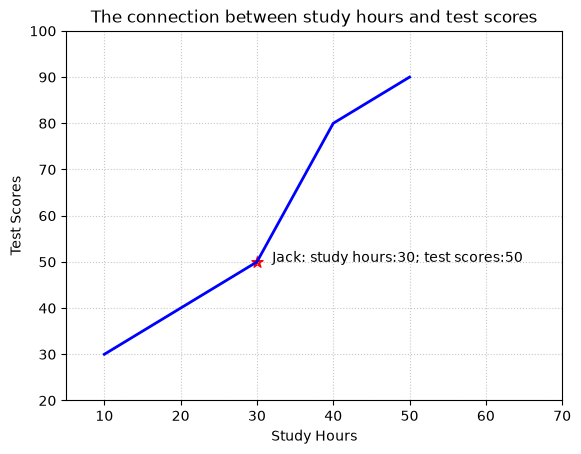

In [4]:
# plt.scatter():plt.scatter(x_value,y_value,color = "color",marker = "shape",s = size)
# plt.title(): plt.title("str")
# plt.xlim():plt.xlim(int,int)
# plt.ylim():plt.ylim(int,int)
# plt.xlabel():plt.xlabel("str")
# plt.ylabel():plt.ylabel("str")
# plt.grid():plt.grid(True,linestyle = "linestyle",alpha = transparency)
# plt.plot():plt.plot(x_value,y_value,color = "color",linestyle,linewidth)
# plt.text():plt.text(int,int,"str")


study_hours = [10,20,30,40,50]
test_scores = [30,40,50,80,90]
plt.scatter(30,50,color = "red",marker = "*",s = 70)
plt.title("The connection between study hours and test scores")
plt.xlim(5,70)
plt.ylim(20,100)
plt.xlabel("Study Hours")
plt.ylabel("Test Scores")
plt.grid(True,linestyle = ":",alpha = 0.7)
plt.plot(study_hours,test_scores,color ="blue",linestyle ="-",linewidth =2)
plt.text(32,50,"Jack: study hours:30; test scores:50")


2. The mystery fruit and KNN

Here is your mystery fruit: Weight:1147 g. Sweetness:2.
Nearest neighbours: ['watermelon', 'watermelon']
Lemon votes: 0, watermelon votes: 2.
Prediction: It is probably a watermelon


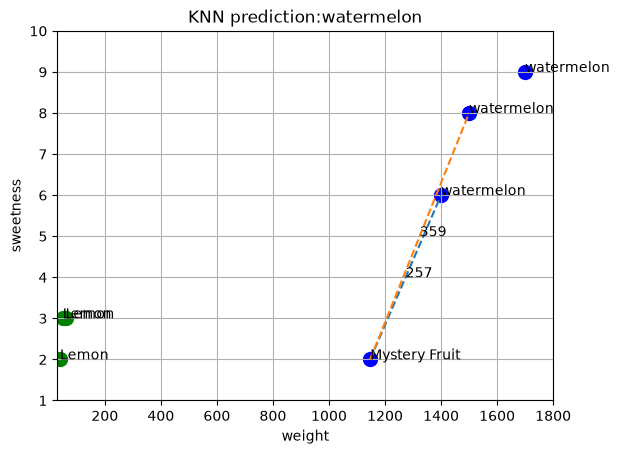

In [5]:
import random

# 1. known fruit:[weight, sweetness, name]
fruits = [
    [1500,8,"watermelon"],
    [1400,6,"watermelon"],
    [1700,9,"watermelon"],
    [40,2,"Lemon"],
    [50,3,"Lemon"],
    [60,3,"Lemon"],
]

# 2. create a mystery fruit
mystery_weight = random.randint(30,1800)
mystery_sweetness = random.randint(1,10)

print(f"Here is your mystery fruit: Weight:{mystery_weight} g. Sweetness:{mystery_sweetness}.")

k = int(input("Please enter k (1 or 3): "))

# 3. calculate the distance to the known fruit
scored_fruits = []
for fruit in fruits:
    weight = fruit[0]
    sweetness = fruit[1]
    name = fruit[2]
    distance = abs(mystery_weight-weight) + abs(mystery_sweetness-sweetness)
    scored_fruits.append([distance,weight,sweetness,name])
    
# 4. put the closest fruit first
scored_fruits.sort()
closest_neighbours = scored_fruits[:k]

# 5. collect the votes
votes = []
for neighbour in closest_neighbours:
    votes.append(neighbour[3])
print(f"Nearest neighbours: {votes}")

# 6.count the votes
Lemon_votes = votes.count("Lemon")
watermelon_votes = votes.count("watermelon")
print(f"Lemon votes: {Lemon_votes}, watermelon votes: {watermelon_votes}.")

# 7. make the final prediction
prediction = "watermelon" if watermelon_votes > Lemon_votes else "Lemon"
print( f"Prediction: It is probably a {prediction}")

# 8. draw the known fruits
for fruit in fruits:
    weight = fruit[0]
    sweetness = fruit[1]
    name = fruit[2]
    
    if name == "Lemon":
        fruit_color = "green"
    else:
        fruit_color = "blue"
    plt.scatter(weight,sweetness,color = fruit_color,s = 100)
    plt.text(weight,sweetness,name)
  
# 9. draw the mystery fruit
plt.scatter(mystery_weight,mystery_sweetness,color = "blue",s = 100)
plt.text(mystery_weight,mystery_sweetness,"Mystery Fruit")

# 10. draw the lines to the cloest neighbours
for neighbour in closest_neighbours:
    distance = neighbour[0]
    weight = neighbour[1]
    sweetness = neighbour [2]
    
    plt.plot([mystery_weight,weight],[mystery_sweetness,sweetness],linestyle = "--")
    middle_weight = (mystery_weight+weight)/2
    middle_sweetness = (mystery_sweetness+sweetness)/2
    
    plt.text(middle_weight,middle_sweetness,str(distance))

# 11. complete the chart
plt.title(f"KNN prediction:{prediction}")
plt.xlabel("weight")
plt.ylabel("sweetness")
plt.xlim(30,1800)
plt.ylim(1,10)
plt.grid(True)
plt.show()


## Session 4

1. UGOT camera image

In [ ]:
got.open_camera()
print("The camera is on.")
picture_raw = got.read_camera_data()
picture_1D = np.frombuffer(picture_raw,np.uint8)
picture_bgr = cv2.imdecode(picture_1D,cv2.IMREAD_COLOR)  
ok,picture_jpg = cv2.imencode(".jpg",picture_bgr)
display(Image(picture_jpg.tobytes()))

2. OpenCV and laptop camera

In [ ]:
# take a selfy
import time

# open the laptop camera
camera  = cv2.VideoCapture(0,cv2.CAP_AVFOUNDATION)  # windows: DSHOW
time.sleep(1)
print("The laptop camera is on.")

frame_ok, frame = camera.read()

if frame_ok:
    jpeg_ok,jpeg = cv2.imencode(".jpeg",frame)
    if jpeg_ok:
        display(Image(data = jpeg.tobytes()))
else:
    print("The camera can not be found.")
    
camera.release()

In [ ]:
# take three selfies
import time
# open the laptop camera
camera  = cv2.VideoCapture(0,cv2.CAP_AVFOUNDATION)  # windows: DSHOW
time.sleep(1)
print("The laptop camera is on.")

for i in range(3):
    frame_ok, frame = camera.read()

    if frame_ok:
        jpeg_ok,jpeg = cv2.imencode(".jpeg",frame)
        if jpeg_ok:
            display(Image(data = jpeg.tobytes()))
    else:
        print("The camera can not be found.")
    time.sleep(2)
        
camera.release()

3. take vdieo using laptop camera

In [ ]:
import time
# open the laptop camera
camera  = cv2.VideoCapture(0,cv2.CAP_AVFOUNDATION)  # windows: DSHOW
time.sleep(1)

if not camera.isOpened():
    print("The camera is not opened.")
else:
    print("The laptop camera is on.")
    time.sleep(1)
    
    handle = None
    start_time = time.time()
    
    while time.time()-start_time < 5:
        frame_ok, frame = camera.read()
        if frame_ok:
            jpeg_ok,jpeg = cv2.imencode(".jpeg",frame)
            if jpeg_ok:
                if handle is None:
                    handle = display(Image(data = jpeg.tobytes()),display_id = True) # create a handle to show the images
                else:
                    handle.update (Image(data = jpeg.tobytes())) # update the same handle
        time.sleep(0.02)

    camera.release()

## Practice

In [ ]:
# practice

start_time = time.time()
camera.release()
camera = cv2.VideoCapture(0,cv2.CAP_AVFOUNDATION)
else:
print("The camera is on.")
time.sleep(1)
camera = cv2.VideoCapture(0,cv2.CAP_AVFOUNDATION)
while time.time()- start_time < 5:
print("The camera is not opened.")
handle = display(Image(data=jpeg.tobytes()),display_id=True)
time.sleep(0.02)
else:
handle.update(Image(data=jpeg.tobytes())) 
if jpeg_ok: # create the display area for the first time
if handle is None:
if frame_ok:
jpeg_ok,jpeg = cv2.imencode(".jpg",frame)
if not camera.isOpened():
handle = None
time.sleep(1)
import time
frame_ok, frame = camera.read()
